In [2]:
# Linear regression is a statistical method that allows the prediction of an outcome based on the relationship between two variables.  In this case
# predictions are made using student's test scored based on the number of hours they studied.  To build this model, a process called "train-test split"
# is used.  By using 80% of the historical student data into the algorithm it could learn the underlying pattern, with 20% of the remaining data 
# hidden.  This 20% will be used as measure for how accurately the model predicted the real-world results.  

In [3]:
# R-squared is used to measure the accuracy of the model.  Essentially R-squared represents the percentage of the test scores that can be explained
# directly by the hours studied.  With the model achieving an accuracy of .945 or 94.5% this means that 94.5% of student's test score variation 
# is driven by study time.  

In [4]:
# Import necessary libraries for data manipulation, mathematical operations, and visualization
# pandas is used for data manipulation and analysis
# Imported matplotlib.pyplot library for the plotting of selected data
# seaborn is built on top of matplotlib and is used for the generation statistical graphics much easier
# numpy provides support for high-performance mathematical operations and multi-dimensional arrays
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
#  Imported txt file and assigned it to the variable ‘data’
data = pd.read_csv('student_scores.csv')

In [6]:
#  prints the first 5 lines of the dataset ‘data’
data.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [7]:
#  reads the datatype in the column of the dataset ‘data’
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [8]:
# Generate descriptive statistics (count, mean, std, min, max, and percentiles) for the dataset
data.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


<Figure size 1200x600 with 0 Axes>

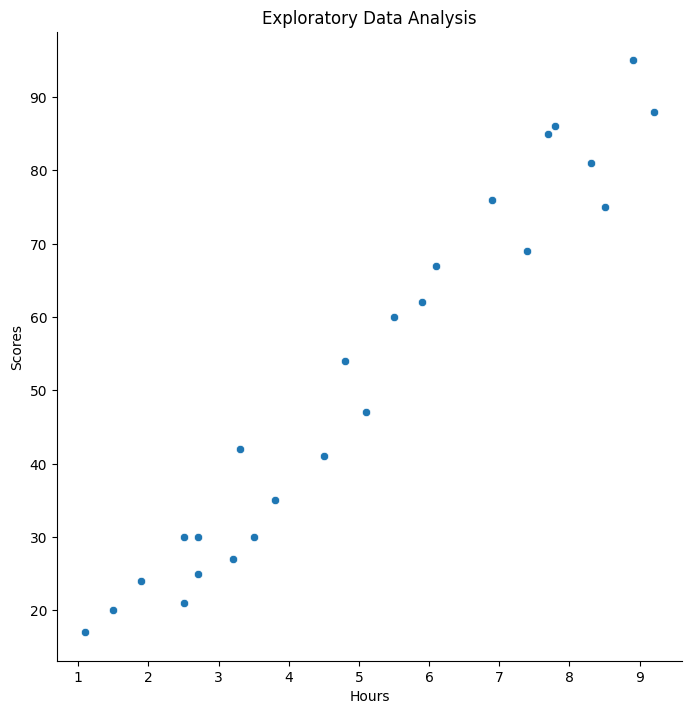

In [9]:
# Exploratory Data Analysis takes the raw values from the dataset data and plots it on a scatterplot
# Since this is not a test prediction assigned it the label Exploratory Data Analysis
# Retrieves dataset from the selection variable and assigns it to the X and Y variable for plotting as a scatterplot. 
# Creates a new plotting canvas and set its size to 12 inches wide by 6 inches tall
# Assigns 'Hours' to the X coordinate, 'Scores' to the Y coordinates, with a height of 7 as a scatterplot
# labels X,Y with a title then prints out the plot from the assigned values
plt.figure(figsize=(12,6))
sns.pairplot(data,x_vars=['Hours'],y_vars=['Scores'],height=7,kind='scatter')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.title('Exploratory Data Analysis')
plt.show()

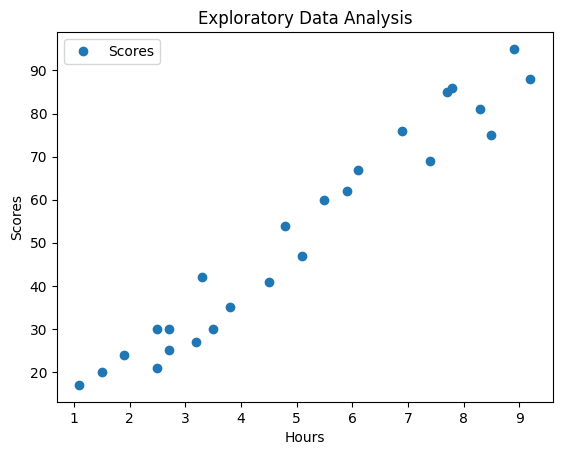

In [10]:
# Exploratory Data Analysis takes the raw values from the dataset data and plots it on a scatterplot
# Since this is not a test prediction assigned it the label Exploratory Data Analysis
# Assigns 'Hours' to the X coordinate, 'Scores' to the Y coordinates, with a style of 'o' to plot discrete plot points
# labels X,Y with a title then prints out the plot from the assigned values
data.plot(x='Hours', y='Scores', style='o')
plt.title('Exploratory Data Analysis')
plt.xlabel('Hours')
plt.ylabel('Scores')
plt.show()

In [11]:
# Assign the 'Hours' column to the variable of X and prints out the first 5 lines
X = data[['Hours']]
X.head()

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5


In [12]:
# Print the data type of hours
type(X)

pandas.DataFrame

In [13]:
# Assign the 'Scores' column to the variable of Y and prints out the first 5 lines
y = data['Scores']
y.head()

0    21
1    47
2    27
3    75
4    30
Name: Scores, dtype: int64

In [14]:
# Print the data type of Scores
type(y)

pandas.Series

In [15]:
# Import the train_test_split model class from scikit-learn's library
# train_test_split is used for split arrays or matrices into random train and test subsets
from sklearn.model_selection import train_test_split

In [16]:
# Splits the data in columns X,Y and assigns train and test routines with a train_size 80% and test size 20%
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=0)

In [17]:
# Import the linear Regression model class from scikit-learn's library
# LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed 
# targets in the dataset, and the targets predicted by the linear approximation
from sklearn.linear_model import LinearRegression

In [18]:
# Assigned lr and variables for LinearRegression 
# Train the model using our training datasets
# The .fit() method calculates the optimal line of best fit between the Hours and Scores
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# Use the trained model to generate predicted test scores (y_pred) 
# based on our testing dataset of hours studied (X_test)
y_pred = lr.predict(X_test)

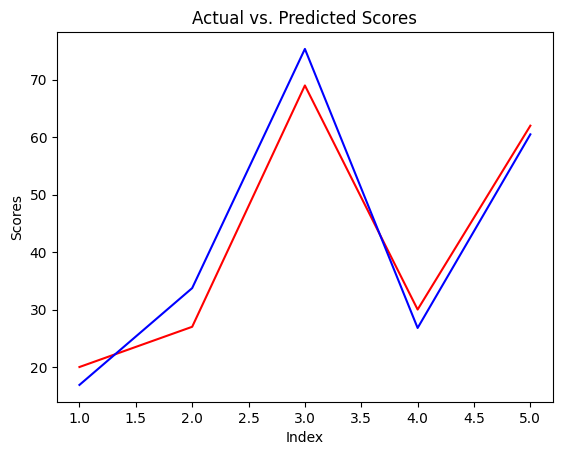

In [20]:
# Visualize the Actual Test Scores vs. the Predicted Test Scores
# Creates a index 'c' for the x-axis to line up the actual and predicted values side-by-side
# Rather than it being labeled 'Hours' and 'Scores' it should be labled 'Actual and Predicted Scores' to represent the output of the data
c = [i for i in range (1,len(y_test)+1,1)]
plt.plot(c,y_test,color='r',linestyle='-', label='Actual Scores')
plt.plot(c,y_pred,color='b',linestyle='-', label='Predicted Scores')
plt.xlabel('Index')
plt.ylabel('Scores')
plt.title('Actual vs. Predicted Scores')
plt.show()

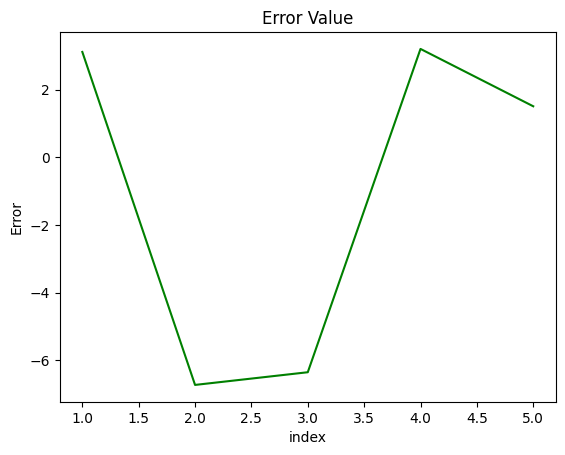

In [21]:
# Visualize the Error Values (Residuals).
# Creates a index 'c' to represent each individual student in our test set
# Plot the difference between the Actual Score and the Predicted Score (y_test - y_pred)
c = [i for i in range(1,len(y_test)+1,1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()

In [22]:
# Import the metrics class from scikit-learn's library
from sklearn import metrics
# Calculate and print summary statistics to see how far off our predictions were on average (MAE, MSE, RMSE)
# Mean Absolute Error (MAE) takes all those errors, turns any negative errors into positive ones (so they don't cancel each other out), and just finds the average
# Mean Squared Error (MSE) squares every single error before averaging them. Squaring them purposefully "punishes" the model for making really big mistakes, making them highly visible
# Root Mean Squared Error (RMSE) squared the numbers, the result is in "squared points".  RMSE takes the square root to bring the number back down to normal test score points
# R-Squared is an accuracy score. It tells you how well your model explains the data. Score of roughly 0.945 means the model accounted for 94.5% of the variation in the scores
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('r square :' , metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 4.183859899002975
Mean Squared Error: 21.598769307217406
Root Mean Squared Error: 4.647447612100367
r square : 0.9454906892105355


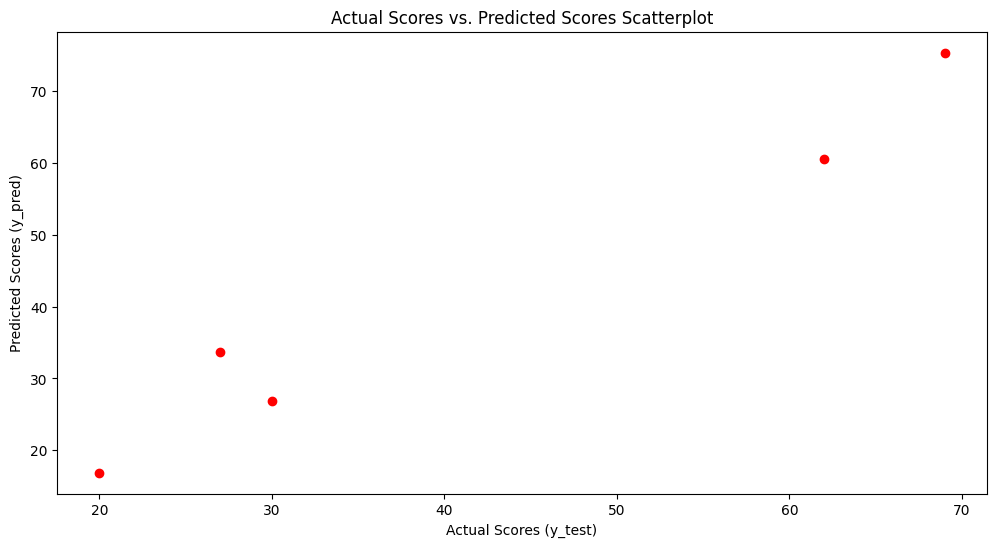

In [23]:
# Visualize the Actual Scores vs. Predicted Scores Scatterplot
plt.figure(figsize=(12,6))
plt.scatter(y_test,y_pred,color='r',linestyle='-')
plt.xlabel('Actual Scores (y_test)')
plt.ylabel('Predicted Scores (y_pred)')
plt.title('Actual Scores vs. Predicted Scores Scatterplot')
plt.show()

In [24]:
# Print the mathematical components of our line of best fit (y = mx + b)
# The Intercept is where the line crosses the y-axis (when Hours = 0)
# Coefficient (slope) tells how much the score is expected to increase for every 1 extra hour studied
print('Intercept of the model:',lr.intercept_)
print('Coefficient of the line:',lr.coef_)

Intercept of the model: 2.0181600414346974
Coefficient of the line: [9.91065648]


In [25]:
# conducted a test to evaluate the predicted values
import pandas as pd

new_hours = pd.DataFrame([[2.5]], columns=['Hours'])

new_prediction = lr.predict(new_hours)

print("Hours Studied:", new_hours.iloc[0]['Hours'])
print("Predicted Test Score:", new_prediction[0])

Hours Studied: 2.5
Predicted Test Score: 26.79480124304028
